In [1]:
# Final Project - Group 2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV


from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.tree import export_graphviz
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, auc

In [2]:
# identify folder path
folder_path = r'C:\Users\thigl\Downloads\\Data'

In [3]:
# combine yearly datasets into one
dfs = []

for root, dirs, files in os.walk(folder_path):
    for filename in files:
        file_path = os.path.join(root, filename)
        if filename.endswith(".xlsx"):
            print(file_path)
            df_raw = pd.read_excel(file_path)
            df_raw['Source'] = filename
            df_raw['Filepath'] = file_path

            dfs.append(df_raw)

df_all = pd.concat(dfs, ignore_index = True)

C:\Users\thigl\Downloads\\Data\all_incidents_combined.xlsx


In [4]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 481960 entries, 0 to 481959
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   the_geom              464630 non-null  object        
 1   cartodb_id            481960 non-null  int64         
 2   the_geom_webmercator  464513 non-null  object        
 3   objectid              481960 non-null  int64         
 4   dc_dist               481960 non-null  int64         
 5   psa                   481831 non-null  object        
 6   dispatch_date_time    481960 non-null  object        
 7   dispatch_date         481960 non-null  datetime64[ns]
 8   dispatch_time         481960 non-null  object        
 9   hour                  381341 non-null  float64       
 10  dc_key                481960 non-null  int64         
 11  location_block        481888 non-null  object        
 12  ucr_general           481960 non-null  int64         
 13 

In [5]:
# export to excel
# output = r'C:\Users\saman\Documents\DSS 740 Machine Learning\Final Project\Data\all_incidents_combined.xlsx'
# df_all.to_excel(output, index = False, freeze_panes = (1,0))

In [6]:
# reload the data
file = r"C:\Users\thigl\Downloads\Data\all_incidents_combined.xlsx"
df = pd.read_excel(file)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 481960 entries, 0 to 481959
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   the_geom              464630 non-null  object        
 1   cartodb_id            481960 non-null  int64         
 2   the_geom_webmercator  464513 non-null  object        
 3   objectid              481960 non-null  int64         
 4   dc_dist               481960 non-null  int64         
 5   psa                   481831 non-null  object        
 6   dispatch_date_time    481960 non-null  object        
 7   dispatch_date         481960 non-null  datetime64[ns]
 8   dispatch_time         481960 non-null  object        
 9   hour                  381341 non-null  float64       
 10  dc_key                481960 non-null  int64         
 11  location_block        481888 non-null  object        
 12  ucr_general           481960 non-null  int64         
 13 

In [8]:
# make dispatch date time a date format & convert to Eastern tz
df['dispatch_date_time'] = pd.to_datetime(df['dispatch_date_time'], utc= True)

df['dispatch_date_time'] = df['dispatch_date_time'].dt.tz_convert("America/New_York")

df['dispatch_date_time'] = df['dispatch_date_time'].dt.tz_convert("America/New_York").dt.tz_localize(None)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 481960 entries, 0 to 481959
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   the_geom              464630 non-null  object        
 1   cartodb_id            481960 non-null  int64         
 2   the_geom_webmercator  464513 non-null  object        
 3   objectid              481960 non-null  int64         
 4   dc_dist               481960 non-null  int64         
 5   psa                   481831 non-null  object        
 6   dispatch_date_time    481960 non-null  datetime64[ns]
 7   dispatch_date         481960 non-null  datetime64[ns]
 8   dispatch_time         481960 non-null  object        
 9   hour                  381341 non-null  float64       
 10  dc_key                481960 non-null  int64         
 11  location_block        481888 non-null  object        
 12  ucr_general           481960 non-null  int64         
 13 

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 481960 entries, 0 to 481959
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   the_geom              464630 non-null  object        
 1   cartodb_id            481960 non-null  int64         
 2   the_geom_webmercator  464513 non-null  object        
 3   objectid              481960 non-null  int64         
 4   dc_dist               481960 non-null  int64         
 5   psa                   481831 non-null  object        
 6   dispatch_date_time    481960 non-null  datetime64[ns]
 7   dispatch_date         481960 non-null  datetime64[ns]
 8   dispatch_time         481960 non-null  object        
 9   hour                  381341 non-null  float64       
 10  dc_key                481960 non-null  int64         
 11  location_block        481888 non-null  object        
 12  ucr_general           481960 non-null  int64         
 13 

In [10]:
# create month col
df['Month'] = df['dispatch_date_time'].dt.month

# create day of week col
# 0 = Mon, 1 = Tues, 2 = Wed, 3 = Thurs, 4 = Fri, 5 = Sat, 6 = Sun    - so 5 and 6 would be considered weekends (unless you want to combine Friday into the weekend then itd be 4,5,6)
df['Day of Week'] = df['dispatch_date_time'].dt.dayofweek
df

,the_geom,cartodb_id,the_geom_webmercator,objectid,dc_dist,psa,dispatch_date_time,dispatch_date,dispatch_time,hour,...,ucr_general,text_general_code,point_x,point_y,lat,lng,Source,Filepath,Month,Day of Week
0,NaN,32953,NaN,38492237,18,2,2023-06-07 00:00:00,2023-06-07,00:00:00,14.0,...,100,Homicide - Criminal,NaN,NaN,NaN,NaN,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,6,2
1,NaN,32954,NaN,38492238,22,4,2023-07-09 00:00:00,2023-07-09,00:00:00,18.0,...,100,Homicide - Criminal,NaN,NaN,NaN,NaN,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,7,6
2,0101000020E61000001C6EA3DBD4C952C0E84286A4C206...,33106,0101000020110F0000FF8EC196FBE95FC16FB5DF0B6597...,38492364,35,NaN,2023-04-25 00:00:00,2023-04-25,00:00:00,4.0,...,100,Homicide - Criminal,-75.153617,40.052815,40.052815,-75.153617,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,4,1
3,0101000020E61000002C3C1A7AB0C452C050FDE06FC004...,34484,0101000020110F0000F4FB52953FE15FC180DD5C942A95...,38493394,2,1,2023-01-19 00:00:00,2023-01-19,00:00:00,20.0,...,100,Homicide - Criminal,-75.073271,40.037123,40.037123,-75.073271,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,1,3
4,0101000020E61000009057D535F4CA52C070C0B34C65F8...,34493,0101000020110F000085F48BAFE3EB5FC1EF9E0C3C7887...,38493403,17,1,2023-07-26 00:00:00,2023-07-26,00:00:00,19.0,...,100,Homicide - Criminal,-75.171155,39.940591,39.940591,-75.171155,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,7,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
481955,0101000020E61000008F60BA7B06C452C005BEC3699804...,3529167,0101000020110F00009B68FCD41EE05FC16793972EFE94...,24725718,15,3,2025-01-09 20:27:00,2025-01-09,20:27:00,20.0,...,600,Thefts,-75.062896,40.035901,40.035901,-75.062896,2025 incidents-use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,1,3
481956,0101000020E610000045362593B2C152C016440F42E10C...,3529168,0101000020110F0000DCB9129F2ADC5FC178209DE12F9E...,24784024,7,2,2025-01-13 15:46:00,2025-01-13,15:46:00,15.0,...,600,Thefts,-75.026524,40.100624,40.100624,-75.026524,2025 incidents-use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,1,0
481957,0101000020E610000045362593B2C152C016440F42E10C...,3529177,0101000020110F0000DCB9129F2ADC5FC178209DE12F9E...,24784029,7,2,2025-01-22 16:09:00,2025-01-22,16:09:00,16.0,...,600,Thefts,-75.026524,40.100624,40.100624,-75.026524,2025 incidents-use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,1,2
481958,0101000020E61000000044D16EBACA52C039E9011C10F8...,3529178,0101000020110F00009A8B848B81EB5FC191A596DE1987...,24359601,17,1,2025-01-06 16:53:00,2025-01-06,16:53:00,16.0,...,600,Thefts,-75.167629,39.937992,39.937992,-75.167629,2025 incidents-use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,1,0


In [11]:
# create season col
df['Season'] = df['Month'].map({
    1: "Winter", 2: "Winter", 12: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Fall", 10: "Fall", 11: "Fall", 
})
df

,the_geom,cartodb_id,the_geom_webmercator,objectid,dc_dist,psa,dispatch_date_time,dispatch_date,dispatch_time,hour,...,text_general_code,point_x,point_y,lat,lng,Source,Filepath,Month,Day of Week,Season
0,NaN,32953,NaN,38492237,18,2,2023-06-07 00:00:00,2023-06-07,00:00:00,14.0,...,Homicide - Criminal,NaN,NaN,NaN,NaN,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,6,2,Summer
1,NaN,32954,NaN,38492238,22,4,2023-07-09 00:00:00,2023-07-09,00:00:00,18.0,...,Homicide - Criminal,NaN,NaN,NaN,NaN,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,7,6,Summer
2,0101000020E61000001C6EA3DBD4C952C0E84286A4C206...,33106,0101000020110F0000FF8EC196FBE95FC16FB5DF0B6597...,38492364,35,NaN,2023-04-25 00:00:00,2023-04-25,00:00:00,4.0,...,Homicide - Criminal,-75.153617,40.052815,40.052815,-75.153617,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,4,1,Spring
3,0101000020E61000002C3C1A7AB0C452C050FDE06FC004...,34484,0101000020110F0000F4FB52953FE15FC180DD5C942A95...,38493394,2,1,2023-01-19 00:00:00,2023-01-19,00:00:00,20.0,...,Homicide - Criminal,-75.073271,40.037123,40.037123,-75.073271,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,1,3,Winter
4,0101000020E61000009057D535F4CA52C070C0B34C65F8...,34493,0101000020110F000085F48BAFE3EB5FC1EF9E0C3C7887...,38493403,17,1,2023-07-26 00:00:00,2023-07-26,00:00:00,19.0,...,Homicide - Criminal,-75.171155,39.940591,39.940591,-75.171155,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,7,2,Summer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
481955,0101000020E61000008F60BA7B06C452C005BEC3699804...,3529167,0101000020110F00009B68FCD41EE05FC16793972EFE94...,24725718,15,3,2025-01-09 20:27:00,2025-01-09,20:27:00,20.0,...,Thefts,-75.062896,40.035901,40.035901,-75.062896,2025 incidents-use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,1,3,Winter
481956,0101000020E610000045362593B2C152C016440F42E10C...,3529168,0101000020110F0000DCB9129F2ADC5FC178209DE12F9E...,24784024,7,2,2025-01-13 15:46:00,2025-01-13,15:46:00,15.0,...,Thefts,-75.026524,40.100624,40.100624,-75.026524,2025 incidents-use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,1,0,Winter
481957,0101000020E610000045362593B2C152C016440F42E10C...,3529177,0101000020110F0000DCB9129F2ADC5FC178209DE12F9E...,24784029,7,2,2025-01-22 16:09:00,2025-01-22,16:09:00,16.0,...,Thefts,-75.026524,40.100624,40.100624,-75.026524,2025 incidents-use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,1,2,Winter
481958,0101000020E61000000044D16EBACA52C039E9011C10F8...,3529178,0101000020110F00009A8B848B81EB5FC191A596DE1987...,24359601,17,1,2025-01-06 16:53:00,2025-01-06,16:53:00,16.0,...,Thefts,-75.167629,39.937992,39.937992,-75.167629,2025 incidents-use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,1,0,Winter


In [12]:
# create weekday/weekend col
df['Week Type'] = df['Day of Week'].map({
    0: "Weekday", 1: "Weekday", 2: "Weekday", 3: "Weekday", 4: "Weekday",
      5: "Weekend", 6: "Weekend"
})
df

,the_geom,cartodb_id,the_geom_webmercator,objectid,dc_dist,psa,dispatch_date_time,dispatch_date,dispatch_time,hour,...,point_x,point_y,lat,lng,Source,Filepath,Month,Day of Week,Season,Week Type
0,NaN,32953,NaN,38492237,18,2,2023-06-07 00:00:00,2023-06-07,00:00:00,14.0,...,NaN,NaN,NaN,NaN,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,6,2,Summer,Weekday
1,NaN,32954,NaN,38492238,22,4,2023-07-09 00:00:00,2023-07-09,00:00:00,18.0,...,NaN,NaN,NaN,NaN,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,7,6,Summer,Weekend
2,0101000020E61000001C6EA3DBD4C952C0E84286A4C206...,33106,0101000020110F0000FF8EC196FBE95FC16FB5DF0B6597...,38492364,35,NaN,2023-04-25 00:00:00,2023-04-25,00:00:00,4.0,...,-75.153617,40.052815,40.052815,-75.153617,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,4,1,Spring,Weekday
3,0101000020E61000002C3C1A7AB0C452C050FDE06FC004...,34484,0101000020110F0000F4FB52953FE15FC180DD5C942A95...,38493394,2,1,2023-01-19 00:00:00,2023-01-19,00:00:00,20.0,...,-75.073271,40.037123,40.037123,-75.073271,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,1,3,Winter,Weekday
4,0101000020E61000009057D535F4CA52C070C0B34C65F8...,34493,0101000020110F000085F48BAFE3EB5FC1EF9E0C3C7887...,38493403,17,1,2023-07-26 00:00:00,2023-07-26,00:00:00,19.0,...,-75.171155,39.940591,39.940591,-75.171155,2023 incidents_use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,7,2,Summer,Weekday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
481955,0101000020E61000008F60BA7B06C452C005BEC3699804...,3529167,0101000020110F00009B68FCD41EE05FC16793972EFE94...,24725718,15,3,2025-01-09 20:27:00,2025-01-09,20:27:00,20.0,...,-75.062896,40.035901,40.035901,-75.062896,2025 incidents-use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,1,3,Winter,Weekday
481956,0101000020E610000045362593B2C152C016440F42E10C...,3529168,0101000020110F0000DCB9129F2ADC5FC178209DE12F9E...,24784024,7,2,2025-01-13 15:46:00,2025-01-13,15:46:00,15.0,...,-75.026524,40.100624,40.100624,-75.026524,2025 incidents-use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,1,0,Winter,Weekday
481957,0101000020E610000045362593B2C152C016440F42E10C...,3529177,0101000020110F0000DCB9129F2ADC5FC178209DE12F9E...,24784029,7,2,2025-01-22 16:09:00,2025-01-22,16:09:00,16.0,...,-75.026524,40.100624,40.100624,-75.026524,2025 incidents-use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,1,2,Winter,Weekday
481958,0101000020E61000000044D16EBACA52C039E9011C10F8...,3529178,0101000020110F00009A8B848B81EB5FC191A596DE1987...,24359601,17,1,2025-01-06 16:53:00,2025-01-06,16:53:00,16.0,...,-75.167629,39.937992,39.937992,-75.167629,2025 incidents-use.xlsx,C:\Users\saman\Documents\DSS 740 Machine Learn...,1,0,Winter,Weekday


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 481960 entries, 0 to 481959
Data columns (total 24 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   the_geom              464630 non-null  object        
 1   cartodb_id            481960 non-null  int64         
 2   the_geom_webmercator  464513 non-null  object        
 3   objectid              481960 non-null  int64         
 4   dc_dist               481960 non-null  int64         
 5   psa                   481831 non-null  object        
 6   dispatch_date_time    481960 non-null  datetime64[ns]
 7   dispatch_date         481960 non-null  datetime64[ns]
 8   dispatch_time         481960 non-null  object        
 9   hour                  381341 non-null  float64       
 10  dc_key                481960 non-null  int64         
 11  location_block        481888 non-null  object        
 12  ucr_general           481960 non-null  int64         
 13 

In [14]:
# Crime type 
df['text_general_code'].value_counts()

text_general_code
Thefts                                     114365
Other Assaults                              80021
Motor Vehicle Theft                         51747
Vandalism/Criminal Mischief                 44110
All Other Offenses                          44083
Theft from Vehicle                          33607
Fraud                                       25282
Aggravated Assault No Firearm               16152
Burglary Residential                        10384
Aggravated Assault Firearm                   8380
Weapon Violations                            8247
Narcotic / Drug Law Violations               8017
Robbery No Firearm                           7531
Robbery Firearm                              5533
Burglary Non-Residential                     4823
Receiving Stolen Property                    3929
Other Sex Offenses (Not Commercialized)      3309
DRIVING UNDER THE INFLUENCE                  2566
Arson                                        1988
Disorderly Conduct              

In [15]:
#Violent Crimes Target Variable

violent_crimes = [ 
    'Homicide - Criminal',
    'Aggravated Assault Firearm',
    'Aggravated Assault No Firearm',
    'Arson',
    'Burglary Non-Residential',
    'Burglary Residential',
    'Offenses Against Family and Children',
    'Other Sex Offenses (Not Commercialized)',
    'Rape',
    'Robbery Firearm',
    'Robbery No Firearm',
    'Other Assaults'
]

df['is_violent'] = df['text_general_code'].isin(violent_crimes).astype(int)

df['is_violent'].value_counts()

is_violent
0    340124
1    141836
Name: count, dtype: int64

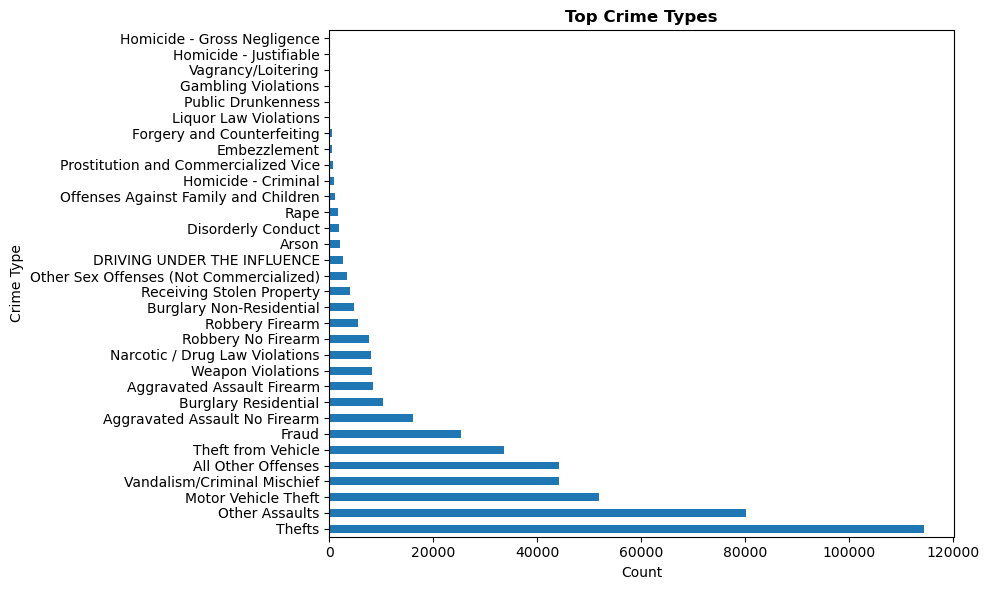

In [16]:
#Top Crime Types

df['text_general_code'].value_counts().plot(kind='barh', figsize=(10, 6))
plt.xlabel('Count')
plt.ylabel('Crime Type')
plt.title('Top Crime Types', fontweight='bold')
plt.tight_layout()
plt.show()

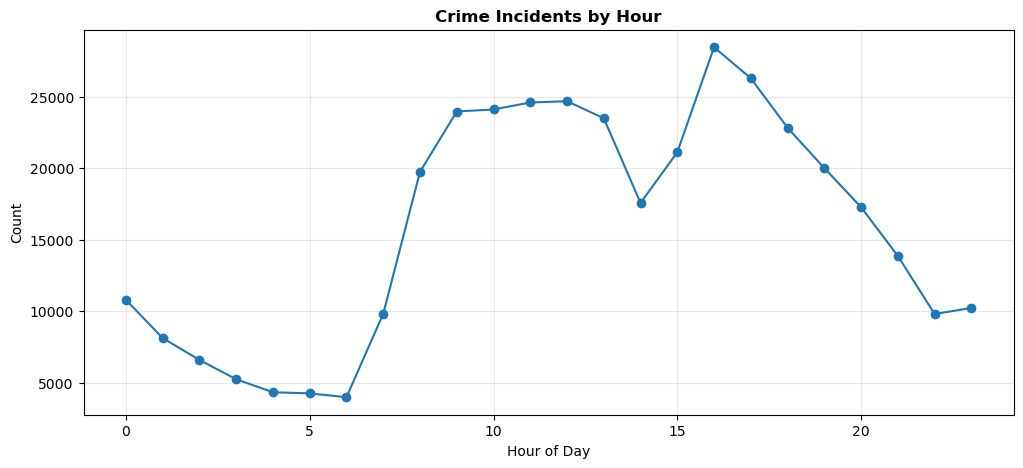

In [17]:
#Crime Incidence by Hour of the Day

df['hour'].value_counts().sort_index().plot(figsize=(12, 5), marker='o')
plt.xlabel('Hour of Day')
plt.ylabel('Count')
plt.title('Crime Incidents by Hour', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

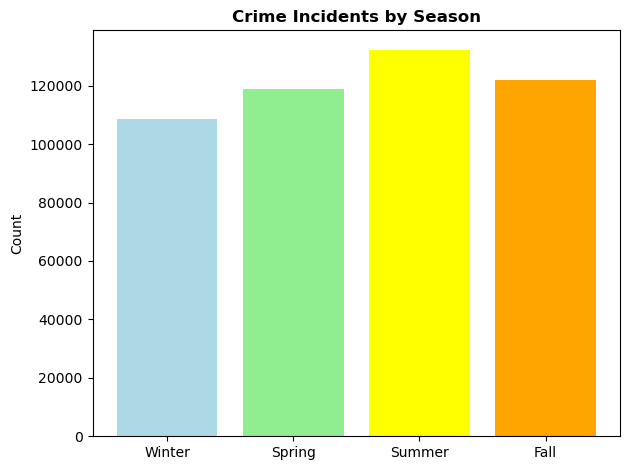

In [20]:
#Season Distribution
season_order = ['Winter', 'Spring', 'Summer', 'Fall']
season_counts = df['Season'].value_counts().reindex(season_order)

plt.bar(season_counts.index, season_counts.values, color = ['lightblue', 'lightgreen', 'yellow','orange'])
plt.ylabel('Count')
plt.title('Crime Incidents by Season', fontweight='bold')
plt.tight_layout()
plt.show()

In [21]:
#District Distribution
df['dc_dist'].value_counts()

dc_dist
15    38374
22    34502
9     32677
24    30937
25    30540
19    28830
14    28513
2     27253
12    26201
35    26116
39    25388
26    21975
18    21209
3     20495
8     19287
16    14973
17    13074
7     11983
1      9538
6      9531
5      7459
77     3104
4         1
Name: count, dtype: int64

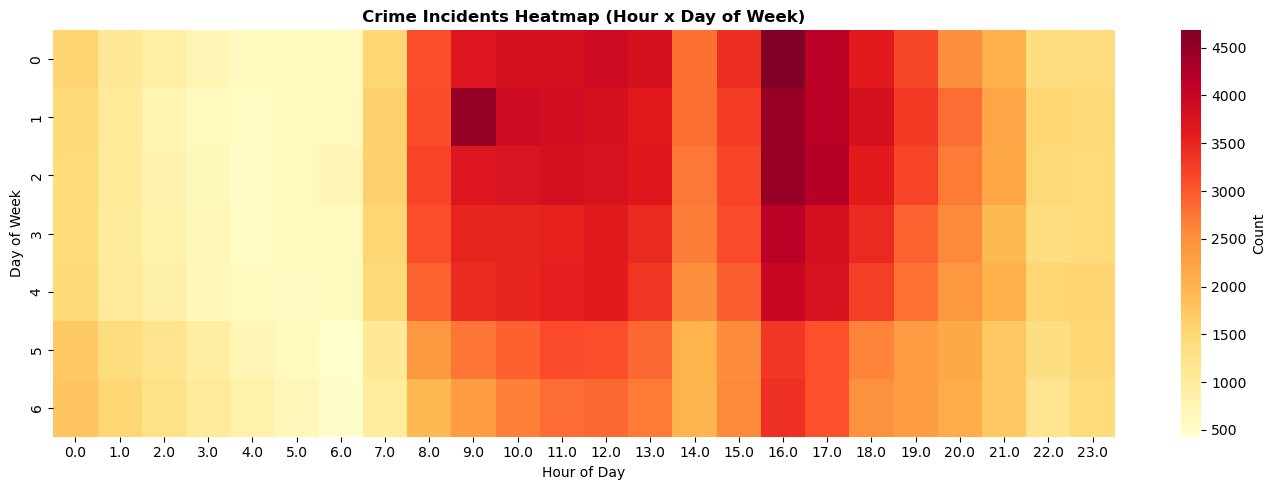

In [22]:
#Crime Incidents Heatmap: Time of Day and Day of Week

pivot_table = df[df['hour'].notna()].pivot_table(
    values='is_violent', 
    index='Day of Week', 
    columns='hour', 
    aggfunc='count'
)

plt.figure(figsize=(14, 5))
sns.heatmap(pivot_table, cmap='YlOrRd', cbar_kws={'label': 'Count'})
plt.title('Crime Incidents Heatmap (Hour x Day of Week)', fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.show()

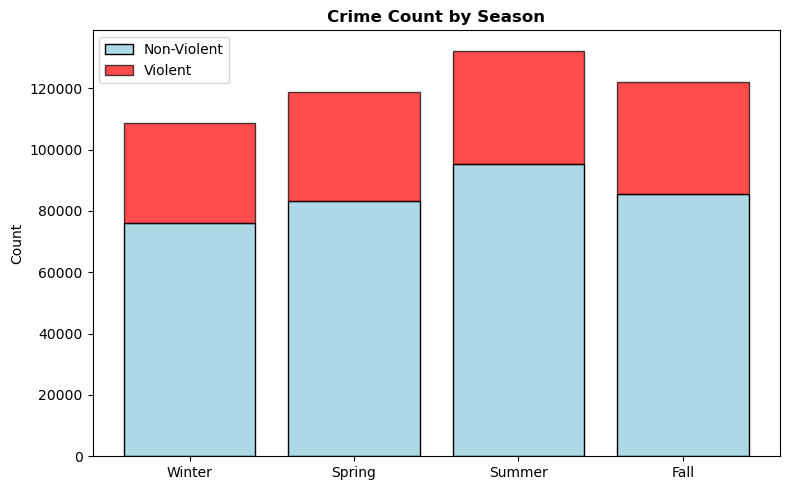

In [23]:
# Violent vs. Non-Violent by Season

violent_by_season = df[df['is_violent'] == 1]['Season'].value_counts().reindex(season_order)
nonviolent_by_season = df[df['is_violent'] == 0]['Season'].value_counts().reindex(season_order)

plt.figure(figsize=(8, 5))
plt.bar(season_order, nonviolent_by_season.values, label='Non-Violent', color='lightblue', edgecolor='black')
plt.bar(season_order, violent_by_season.values, bottom=nonviolent_by_season.values, label='Violent', color='red', edgecolor='black', alpha=0.7)
plt.ylabel('Count')
plt.title('Crime Count by Season', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\thigl\AppData\Local\Temp\ipykernel_13560\524737370.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  violent_by_hour = df[df['hour'].notna()][df['is_violent'] == 1].groupby('hour').size()
C:\Users\thigl\AppData\Local\Temp\ipykernel_13560\524737370.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  nonviolent_by_hour = df[df['hour'].notna()][df['is_violent'] == 0].groupby('hour').size()


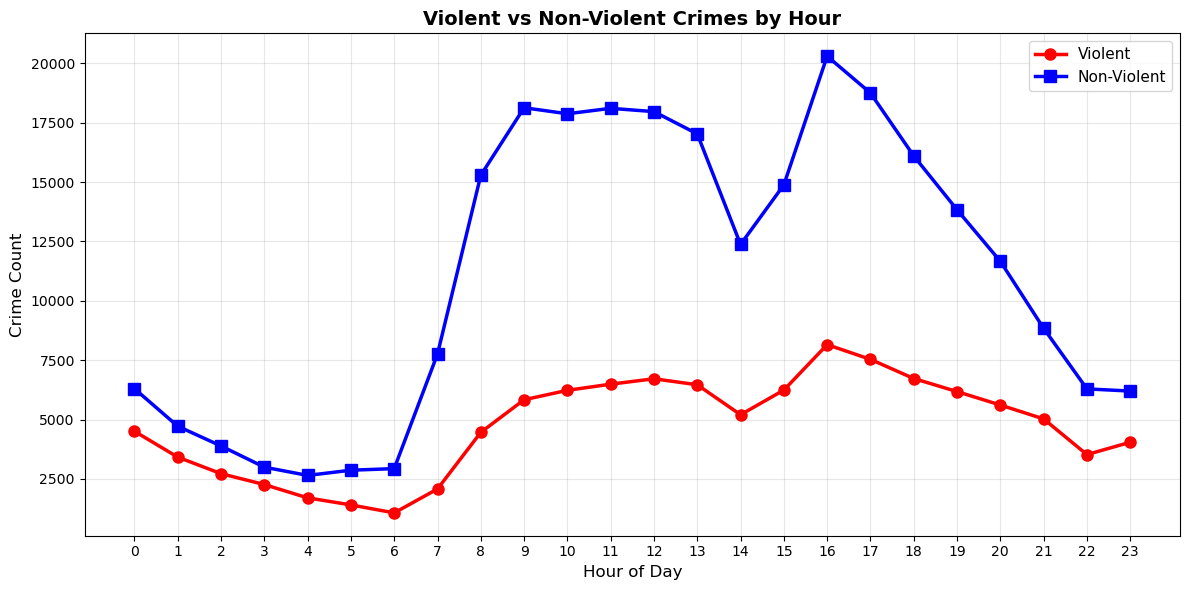

In [24]:
# Violent vs Non-Violent by Hour

violent_by_hour = df[df['hour'].notna()][df['is_violent'] == 1].groupby('hour').size()
nonviolent_by_hour = df[df['hour'].notna()][df['is_violent'] == 0].groupby('hour').size()

plt.figure(figsize=(12, 6))
plt.plot(violent_by_hour.index, violent_by_hour.values, marker='o', linewidth=2.5, markersize=8, label='Violent', color='red')
plt.plot(nonviolent_by_hour.index, nonviolent_by_hour.values, marker='s', linewidth=2.5, markersize=8, label='Non-Violent', color='blue')

plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Crime Count', fontsize=12)
plt.title('Violent vs Non-Violent Crimes by Hour', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(range(0, 24, 1))
plt.tight_layout()
plt.show()

In [25]:
df['location_block'].value_counts()

location_block
5500 BLOCK TULIP ST            1769
2100 BLOCK SOUTH ST            1019
100 BLOCK W CHELTEN AV          848
300 BLOCK E HUNTING PARK AV     754
1500 BLOCK SPRUCE ST            737
                               ... 
E LEHIGH AV & E THOMPSON ST       1
1500 BLOCK S BROAD ST 3RDF        1
Pia Terminal C Checkpoint         1
E PACIFIC ST  & JASPER ST         1
OXFORD AV  & FOULKROD ST          1
Name: count, Length: 63365, dtype: int64

In [26]:
print("Missing Values Count:")
print(df.isnull().sum())

Missing Values Count:
the_geom                 17330
cartodb_id                   0
the_geom_webmercator     17447
objectid                     0
dc_dist                      0
psa                        129
dispatch_date_time           0
dispatch_date                0
dispatch_time                0
hour                    100619
dc_key                       0
location_block              72
ucr_general                  0
text_general_code            0
point_x                  17432
point_y                  17432
lat                      17447
lng                      17447
Source                       0
Filepath                     0
Month                        0
Day of Week                  0
Season                       0
Week Type                    0
is_violent                   0
dtype: int64
